In [1]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import pandas as pd
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)
from laboneq.analysis.fitting import oscillatory

print(laboneq.__version__)

2.51.0


In [2]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.25 14:03:07.066] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.25 14:03:07.069] INFO    VERSION: laboneq 2.51.0
[2025.08.25 14:03:07.071] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.25 14:03:07.080] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.25 14:03:07.086] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.25 14:03:07.093] INFO    Configuring the device setup
[2025.08.25 14:03:07.102] INFO    The device setup is configured


In [3]:
res_lo_freq = 7.2e9
qb_lo_freq = 3.4e9
# qb_freq = 3.10268e9 #Q1
qb_freq = 3.19586e9 #Q2
# qb_freq = 3.19190e9 #Q3
# qb_freq = 3.37406e9 #Q4
# qb_freq =3.37316e9 #Q5
# qb_freq = 3.3990e9 #Q6

# res_freq = 7.14885e9 #Q1
res_freq = 7.18127e9 #Q2
# res_freq = 7.20642e9 #Q3
# res_freq = 7.23025e9 #Q4
# res_freq = 7.26202e9 #Q5
# res_freq = 7.29047e9 #Q6
integration_time = 0.5e-5

amp_min = 0
amp_max = 0.7
amp_num = 201

ro_pulse_amp = 0.1
ro_pulse_length = 5e-6
drive_pulse_amp = 1
drive_pulse_length = 3e-6
drive_range = 0
num_averages = 11  # average number = 2^n, n_max = 17
measure_range = -20  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.9
acquire_range = -30
acquire_amp = 0.9
integration_time = 0.5e-5


In [4]:
# range of pulse amplitude scan
def create_rabi_amp_sweep(amp_min, amp_max, amp_num, uid="rabi_amp"):
    return LinearSweepParameter(uid=uid, start=amp_min, stop=amp_max, count=amp_num)


def create_readout_pulse(
    qubit, length=ro_pulse_length, amplitude=ro_pulse_amp):
    readout_pulse = pulse_library.const(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude)
    return readout_pulse


def create_rabi_drive_pulse(qubit, length=drive_pulse_length, amplitude=drive_pulse_amp):
    return pulse_library.const(
        uid=f"gaussian_drive_q{qubit}", length=length, amplitude=amplitude
    )

In [5]:
# function that returns an amplitude Rabi experiment


def amplitude_rabi(drive_pulse, readout_pulse, amplitude_sweep):
    exp_rabi = Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_rabi.acquire_loop_rt(
        uid="rabi_shots",
        count=pow(2, num_averages),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        # inner loop - real time sweep of Rabi ampitudes
        with exp_rabi.sweep(uid="rabi_sweep", parameter=amplitude_sweep):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_rabi.section(
                uid="qubit_excitation"):
                exp_rabi.play(
                    signal="drive", pulse=drive_pulse, amplitude=amplitude_sweep
                )
            # readout pulse and data acquisition
            with exp_rabi.section(uid="readout_section", play_after="qubit_excitation"):
                # play readout pulse on measure line
                # exp_rabi.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_rabi.measure(
                    measure_signal='measure',
                    measure_pulse=readout_pulse,
                    acquire_signal="acquire",
                    integration_length = integration_time,
                    handle="amp_rabi",
                    reset_delay = 1e-6,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_rabi.section(uid="reserve", length=600e-6):
                exp_rabi.reserve(signal="measure")
    return exp_rabi

In [6]:
# define pulses and create experiment
readout_pulse = create_readout_pulse("q0")
drive_pulse = create_rabi_drive_pulse("q0")
exp_rabi = amplitude_rabi(drive_pulse, readout_pulse, create_rabi_amp_sweep(amp_min, amp_max, amp_num))


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# run the experiment on qubit 0
exp_rabi.set_signal_map(signal_map_default("q0"))

In [7]:
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = qb_freq -qb_lo_freq, 
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range
)
exp_rabi.set_calibration(exp_calibration)

In [8]:
# compile the experiment on the open instrument session
compiled_rabi = session.compile(exp_rabi)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Rabi", compiled_rabi)

[2025.08.25 14:03:07.173] INFO    Starting LabOne Q Compiler run...
[2025.08.25 14:03:07.220] INFO    Schedule completed. [0.044 s]
[2025.08.25 14:03:07.402] INFO    Code generation completed for all AWGs. [0.179 s]
[2025.08.25 14:03:07.404] INFO    Completed compilation step 1 of 1. [0.227 s]
[2025.08.25 14:03:07.412] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 14:03:07.413] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.25 14:03:07.414] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 14:03:07.415] INFO      device_shfqc        0         14            0           1     20000  
[2025.08.25 14:03:07.416] INFO      device_shfqc_sg     1       1017          202           2     24000  
[2025.08.25 14:03:07.416] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.25 14:03:07.417] INFO      TOTAL                       1031 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Rabi_2025-08-25-14-03-07.html

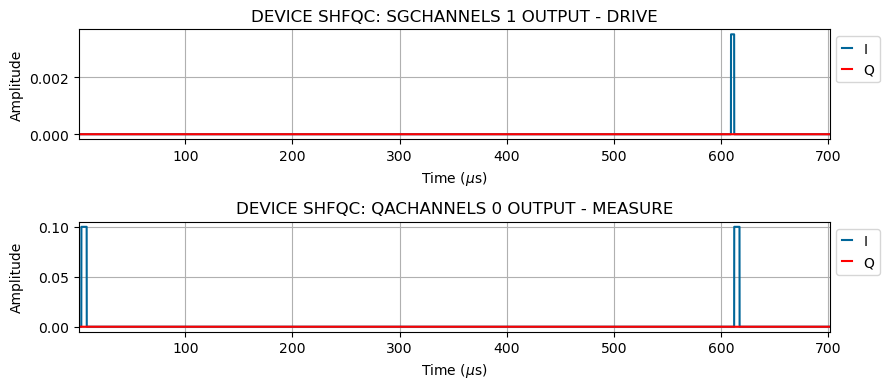

In [9]:
plot_simulation(compiled_rabi, start_time=1e-6, length=700e-6)

In [10]:
# run the compiled experiemnt
rabi_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")

# --- Make output folder + timestamp ---
outdir = "rabi_results"
os.makedirs(outdir, exist_ok=True)


[2025.08.25 14:03:09.328] INFO    Starting near-time execution...
[2025.08.25 14:03:09.399] INFO    Estimated RT execution time: 250.69 s.
[2025.08.25 14:07:20.132] WARNING SHFQC/QA:dev12296: Channel 0 Output overrange count: 3
[2025.08.25 14:07:20.171] INFO    Finished near-time execution.


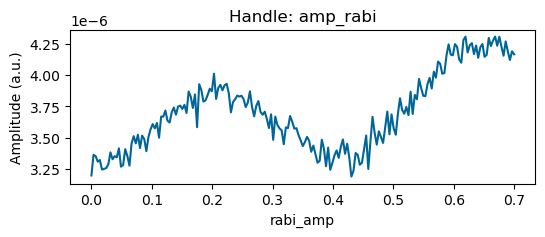

In [11]:
plot_results(rabi_results)

Saved figure to rabi_results\rabi_experiment_20250825T140720Q2.png
Saved data to rabi_results\rabi_experiment_20250825T140720Q2.csv


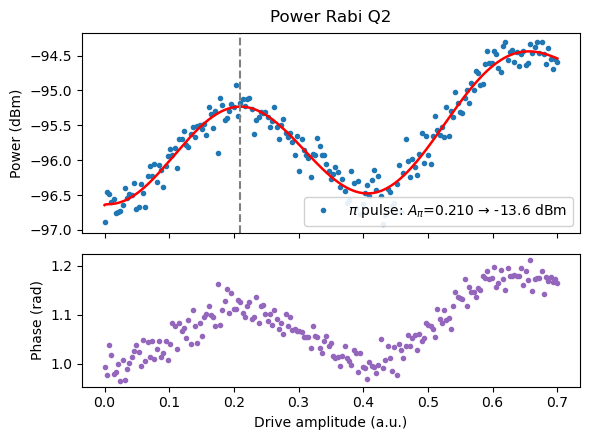

In [12]:
import numpy as np
import os
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

# --- Convert to dBm for the trace (keep your original definition) ---
def to_dbm(signal):
    power_W = (signal**2) / 50.0
    return 10 * np.log10(np.maximum(power_W, 1e-20) / 1e-3)  # avoid log(0)

# --- Data acquisition ---
rabi_res = rabi_results.get_data("amp_rabi")   # complex data
rabi_amp = rabi_results.get_axis("amp_rabi")[0]

# --- Compute quantities ---
amp_abs   = np.abs(rabi_res)
amp_dbm   = to_dbm(amp_abs)
phase_rad = np.angle(rabi_res)
real_dbm  = to_dbm(np.abs(rabi_res.real))
imag_dbm  = to_dbm(np.abs(rabi_res.imag))

# ==========================
# Sophisticated fit function
# ==========================
def rabi_power_model(A, c0, c1, c2, B, A_pi, A0, Adec, p):
    baseline = c0 + c1*A + c2*(A**2)
    osc = B * np.cos(2*np.pi*(A - A0)/np.maximum(A_pi, 1e-12)) \
            * np.exp(- (np.maximum(A,0)/np.maximum(Adec,1e-12))**p)
    return baseline + osc

# --- Initial guesses ---
A = np.asarray(rabi_amp).astype(float)
Y = np.asarray(amp_dbm).astype(float)

coefs = np.polyfit(A, Y, deg=2)
c2_0, c1_0, c0_0 = coefs
B_0 = 0.5 * (np.nanmax(Y) - np.nanmin(Y))

# estimate period
detr = Y - (c0_0 + c1_0*A + c2_0*A**2)
pk, _ = find_peaks(detr, distance=max(2, len(A)//20))
if len(pk) >= 2:
    A_pi_0 = np.median(np.diff(A[pk]))
else:
    A_pi_0 = (A.max() - A.min()) / 4.0

A0_0   = A.min() + 0.25*(A.max()-A.min())
Adec_0 = 0.5*(A.max()-A.min())
p_0    = 1.5

p0 = [c0_0, c1_0, c2_0, B_0, A_pi_0, A0_0, Adec_0, p_0]
lower = [-np.inf, -np.inf, -np.inf, -np.inf, 1e-6, A.min()-2*(A.max()-A.min()), 1e-6, 0.5]
upper = [ np.inf,  np.inf,  np.inf,  np.inf, (A.max()-A.min())*5, A.max()+2*(A.max()-A.min()), (A.max()-A.min())*10, 3.0]

# --- Fit ---
popt, pcov = curve_fit(rabi_power_model, A, Y, p0=p0, bounds=(lower, upper), maxfev=20000)
c0, c1, c2, B, A_pi_fit, A0_fit, Adec_fit, p_fit = popt

# --- Compute fitted curve ---
A_plot = np.linspace(A.min(), A.max(), 5*len(A))
Y_fit  = rabi_power_model(A_plot, *popt)

# --- Find π pulse as the FIRST MAXIMUM of the fitted curve in-range ---
pk, _ = find_peaks(Y_fit, distance=max(2, len(A_plot)//20))
if len(pk) > 0:
    idx_pi = int(pk[0])               # first peak along the sweep
else:
    idx_pi = int(np.argmax(Y_fit))    # fallback

A_pi_point = float(A_plot[idx_pi])    # amplitude (a.u.)
dbm_pi     = 20*np.log10(max(A_pi_point, 1e-12))  # keep your convention

# ===================
# PLOTTING
# ===================
fig, axs = plt.subplots(2, 1, figsize=(6, 4.5),
                        sharex=True, gridspec_kw={'height_ratios': [1.5, 1.0]})

# Amplitude (dBm) + fit
axs[0].plot(rabi_amp, amp_dbm, 'o', ms=3, label="data")
axs[0].plot(A_plot, Y_fit, '-r', lw=1.8, label="fit")
axs[0].axvline(A_pi_point, color="grey", linestyle="--", linewidth=1.5)
axs[0].set_ylabel("Power (dBm)")
axs[0].legend([rf"$\pi$ pulse: $A_\pi$={A_pi_point:.3f} → {dbm_pi:.1f} dBm"],
              loc="lower right", framealpha=0.9)
axs[0].set_title("Power Rabi Q2", fontsize=12, pad=8)

# Phase
axs[1].plot(rabi_amp, phase_rad, 'o', ms=3, color="tab:purple")
axs[1].set_xlabel("Drive amplitude (a.u.)")
axs[1].set_ylabel("Phase (rad)")

plt.tight_layout()

# --- Save figure ---
fig_path = os.path.join(outdir, f"rabi_experiment_{timestamp}Q2.png")
plt.savefig(fig_path, dpi=600)
print(f"Saved figure to {fig_path}")

# --- Save data to CSV ---
df = pd.DataFrame({
    "DriveAmplitude": rabi_amp,
    "Amplitude_dBm": amp_dbm,
    "Real_dBm": real_dbm,
    "Imag_dBm": imag_dbm,
    "Phase_rad": phase_rad,
    "Fit_y(A)": rabi_power_model(rabi_amp, *popt),
})
csv_path = os.path.join(outdir, f"rabi_experiment_{timestamp}Q2.csv")
df.to_csv(csv_path, index=False)
print(f"Saved data to {csv_path}")

plt.show()
